# Task 1 — Augmented Lagrangian solver (plain explanation)

## 1.1 Problem paraphrase (simple language)
We want a program that solves optimization problems with equality and/or inequality constraints.  
A typical problem form is:

Minimize the function $f(x)$ subject to constraints $c_i(x)=0$ (equalities) and $g_j(x)\le 0$ (inequalities).  
In plain words: "find the best $x$ that makes $f(x)$ as small as possible while satisfying the required rules."

## 1.2 Using Augmented Lagrangian (AL):
Augmented Lagrangian is a standard method that turns a constrained problem into a sequence of *unconstrained* problems.  
Instead of solving the constraint problem directly, using AL we build a new function
$$
L_{\mu}(x,\lambda) = f(x) + \lambda^T c(x) + \frac{\mu}{2}\|c(x)\|^2,
$$
where $\lambda$ is a vector of Lagrange multiplier estimates and $\mu>0$ is a penalty weight.

Algorithm idea (brief):
1. Start with a guess $x^{(0)}$, multipliers $\lambda^{(0)}$ and penalty $\mu>0$.
2. Repeat:
   - (Inner) Minimize $L_{\mu}(x,\lambda)$ with respect to $x$ using an *unconstrained* solver (I need to call BFGS solver from project 1 or L-BFGS from scipy package).
   - Update multipliers by $\lambda \leftarrow \lambda + \mu\, c(x)$.
   - Optionally increase $\mu$ if constraint violation is still large.
   - Stop when constraints are satisfied (small $\|c(x)\|$) and $x$ changes little.

**Why it is simple to use:** each inner step is an unconstrained problem — we can plug any robust unconstrained optimizer (BFGS, L-BFGS, trust-region, etc.). The AL outer loop enforces constraints.

## 1.2 Pseudocode (short)
Initialize x, lambda, mu

for k in 0..Kmax:

x = UnconstrainedMinimize( L_mu(x, lambda) ) # inner solve

res = c(x)

if ||res|| < tol: break

lambda = lambda + mu * res

(optional) increase mu

return x, lambda


## 1.3 The inner solver and expected return values
We will call an unconstrained solver that has this contract:

x_opt, info = unconstrained_solver(fun, grad, x0, options)


Where:
- `fun(x)` returns scalar objective value.
- `grad(x)` returns gradient vector (same length as `x`).
- `x_opt` is the found minimizer.
- `info` is a dictionary with at least:
  - `success`: True/False
  - `nit`: number of iterations
  - `message`: short string

The provided code cell below implements:
- an Augmented Lagrangian driver `augmented_lagrangian(...)` that calls an inner solver, and
- our **BFGS + Armijo line search** from project 1 is used (small, easy-to-read) when `scipy` is not available.
We need to call our own unconstrained optimizer by matching the expected contract.



In [ ]:
# Task 1: Augmented Lagrangian + inner unconstrained solver (BFGS fallback)
# This cell provides:
# - a small BFGS+Armijo unconstrained solver (used if scipy not available)
# - an augmented_lagrangian() driver that calls the inner solver
# - clear return-value structure so you can replace the inner solver with your own

import numpy as np
from math import sqrt

# -----------------------
# Small utility: Armijo backtracking line search
# ---------- Hardened Armijo line search ----------
def armijo_line_search_safe(phi, x, p, grad, alpha0=1.0, c=1e-4, tau=0.5, min_alpha=1e-12, max_iter=40):
    """Armijo that detects nan/inf and reduces alpha; returns alpha or 0 if failed."""
    alpha = alpha0
    try:
        fx = phi(x)
    except Exception:
        fx = np.nan
    gtp = float(np.dot(grad, p))
    for it in range(max_iter):
        x_new = x + alpha * p
        try:
            fnew = phi(x_new)
        except Exception:
            fnew = np.nan
        # if fnew is not finite, reduce alpha and continue
        if not np.isfinite(fnew):
            alpha *= tau
            if alpha < min_alpha:
                return 0.0
            continue
        # Armijo condition
        if fnew <= fx + c * alpha * gtp:
            return alpha
        alpha *= tau
        if alpha < min_alpha:
            return 0.0
    return 0.0

# -----------------------
# Simple BFGS unconstrained optimizer (returns x, info)
# ---------- Hardened BFGS fallback (with NaN/Inf checks) ----------
def bfgs_unconstrained_safe(fun, grad, x0, maxiter=300, tol=1e-8):
    """
    BFGS with extra safeguards: rejects steps that produce NaN/Inf, resets H if update invalid.
    Returns x_opt, info dict
    """
    n = len(x0)
    x = x0.astype(float).copy()
    I = np.eye(n)
    H = I.copy()
    fx = fun(x)
    gx = grad(x)
    success = False

    # check initial finiteness
    if not (np.isfinite(fx) and np.all(np.isfinite(gx))):
        return x, {'success': False, 'nit': 0, 'message': 'initial non-finite fun/grad'}

    for k in range(1, maxiter+1):
        gnorm = np.linalg.norm(gx)
        if gnorm < tol:
            success = True
            break

        # compute direction, ensure it's descent and finite
        p = -H.dot(gx)
        if not np.all(np.isfinite(p)) or np.dot(p, gx) >= 0:
            p = -gx  # fallback steepest descent

        # line search (safe)
        alpha = armijo_line_search_safe(lambda z: fun(z), x, p, gx, alpha0=1.0)
        if alpha == 0.0:
            # failed to find usable alpha; try tiny step
            alpha = 1e-8
            x_trial = x + alpha * (-gx)
            f_trial = fun(x_trial)
            if not np.isfinite(f_trial):
                return x, {'success': False, 'nit': k, 'message': 'line-search failed (non-finite)'}
            alpha = 1e-8  # accept tiny step

        s = alpha * p
        x_new = x + s
        gx_new = grad(x_new)

        # check finiteness
        if not (np.all(np.isfinite(x_new)) and np.all(np.isfinite(gx_new)) and np.isfinite(fun(x_new))):
            # reject update and try resetting H
            H = I.copy()
            # try small steepest descent step instead
            s = 1e-8 * (-gx)
            x_new = x + s
            gx_new = grad(x_new)
            if not np.all(np.isfinite(gx_new)):
                return x, {'success': False, 'nit': k, 'message': 'non-finite gradient after recovery step'}
        y = gx_new - gx
        ys = np.dot(y, s)

        # BFGS update only when ys sufficiently large and finite
        if np.isfinite(ys) and abs(ys) > 1e-12:
            # standard BFGS formula for inverse Hessian update
            try:
                V = np.outer(s, y) / ys
                H = (I - V).dot(H).dot(I - V.T) + np.outer(s, s) / ys
            except Exception:
                H = I.copy()
        else:
            # reset H to identity to maintain stability
            H = I.copy()

        x, gx = x_new, gx_new
        fx = fun(x)

    info = {'success': success, 'nit': k, 'message': 'bfgs_safe' if success else 'maxiter_or_fail'}
    return x, info


# -----------------------
# Augmented Lagrangian driver
# -----------------------
def augmented_lagrangian(obj_fun, obj_grad, c_eq, c_eq_jac, x0,
                         inner_solver=bfgs_unconstrained_safe,
                         lambda0=None, mu0=1.0,
                         mu_mult=10.0,
                         max_outer=50, tol_eq=1e-8, verbose=False):
    """
    obj_fun(x) -> scalar
    obj_grad(x) -> gradient vector
    c_eq(x) -> residual vector for equalities (m,)
    c_eq_jac(x) -> Jacobian matrix of equalities (m,n) or function returning same
    inner_solver: function with signature (fun, grad, x0) -> (x_opt, info)
                  where fun and grad are callables for the inner objective.
                  If None, uses bfgs_unconstrained defined above.
    lambda0: initial multipliers (length m). If None uses zeros.
    mu0: initial penalty
    Returns: x, lambda, mu, info
    """
    if inner_solver is None:
        inner_solver = bfgs_unconstrained_safe

    m = len(c_eq(x0))
    x = x0.astype(float).copy()
    lam = np.zeros(m) if lambda0 is None else lambda0.astype(float).copy()
    mu = float(mu0)

    def L_and_grad(x_curr):
        # AL objective and gradient for inner solver
        f = obj_fun(x_curr)
        g = obj_grad(x_curr)
        ce = c_eq(x_curr)
        # Jacobian (m x n)
        J = c_eq_jac(x_curr)
        L = f + float(np.dot(lam, ce)) + 0.5 * mu * float(np.dot(ce, ce))
        gradL = g + J.T.dot(lam + mu * ce)
        return L, gradL

    info_history = []
    prev_eq_norm = np.linalg.norm(c_eq(x))
    for k in range(max_outer):
        # wrap L and grad for inner solver signature
        def fun_inner(z):
            Lval, _ = L_and_grad(z)
            return float(Lval)
        def grad_inner(z):
            _, gradL = L_and_grad(z)
            return gradL

        x_opt, inner_info = inner_solver(fun_inner, grad_inner, x.copy())
        x = x_opt.copy()
        eq_res = c_eq(x)
        eq_norm = np.linalg.norm(eq_res)
        fval = obj_fun(x)
        info_history.append({'outer_iter': k, 'x': x.copy(), 'f': fval, 'eq_norm': eq_norm, 'mu': mu, 'inner': inner_info})

        if verbose:
            print(f"[AL iter {k:2d}] f={fval:.6e}, ||c(x)||={eq_norm:.3e}, mu={mu:.1e}, inner_success={inner_info.get('success',None)}")

        # convergence check on equality residuals
        if eq_norm < tol_eq:
            break

        # multiplier update
        lam = lam + mu * eq_res

        # adapt mu heuristics: increase if residual not decreasing enough
        if eq_norm > 0.5 * prev_eq_norm:
            mu = mu * mu_mult
        prev_eq_norm = eq_norm

    info = {'history': info_history, 'outer_iters': len(info_history)}
    return x, lam, mu, info

# -----------------------
# Example usage template (you will replace obj_fun, obj_grad, c_eq, c_eq_jac)
# -----------------------
if __name__ == "__main__":
    # tiny test problem: minimize (x1-1)^2 + (x2-2)^2 subject to x1 + x2 = 3
    def f_test(x): return (x[0]-1.0)**2 + (x[1]-2.0)**2
    def g_test(x): return np.array([2*(x[0]-1.0), 2*(x[1]-2.0)])
    def ce_test(x): return np.array([x[0] + x[1] - 3.0])
    def Jce_test(x): return np.array([[1.0, 1.0]])  # shape (1,2)

    x0 = np.array([0.5, 0.5])
    x_sol, lam_sol, mu_final, info = augmented_lagrangian(
        obj_fun=f_test, obj_grad=g_test,
        c_eq=ce_test, c_eq_jac=Jce_test,
        x0=x0, inner_solver=bfgs_unconstrained_safe,
        mu0=1.0, mu_mult=10.0, max_outer=30, tol_eq=1e-8, verbose=True
    )
    print("\nSolution:", x_sol, "lambda:", lam_sol, "mu:", mu_final)
    print("Info keys:", info.keys())


[AL iter  0] f=1.280485e-22, ||c(x)||=2.046e-12, mu=1.0e+00, inner_success=True

Solution: [1. 2.] lambda: [0.] mu: 1.0
Info keys: dict_keys(['history', 'outer_iters'])


# **Task 2 — Objective Function and Constraint Definitions**

The chemical equilibrium problem requires minimizing the Gibbs free energy

$$
f(x) \;=\; \sum_{j=1}^{10} x_j \left(c_j + \ln\left(\frac{x_j}{s}\right)\right),
$$

where

$$
s = \sum_{j=1}^{10} x_j.
$$

Because the mixture contains **strictly positive** mole quantities, we enforce a
numerically safe objective by replacing the undefined terms $\ln(0)$ and $1/s$
with smooth lower-bounds:

- Replace all $x_j$ with $\max(x_j,\varepsilon)$  
- Replace $s$ with $\max(s,\varepsilon)$  
- Use a small constant $\varepsilon = 10^{-12}$

Thus the **implemented objective** is

$$
\tilde f(x)
=
\sum_{j=1}^{10}
x_j \left(
c_j + \ln\left(
\frac{\max(x_j,\varepsilon)}{\max\left(\sum_{k=1}^{10} x_k,\; \varepsilon\right)}
\right)
\right).
$$

This preserves the true Gibbs energy for all feasible physical points but
remains well-defined during the intermediate iterations of the optimization
process (where the AL method must evaluate possibly infeasible points).

---

## **Equality Constraints**

The chemical mixture must respect atomic conservation for Hydrogen (H),
Nitrogen (N), and Oxygen (O).  
These are linear equality constraints of the form $c(x)=0$:

### **Hydrogen balance**
$$
x_1 + 2x_2 + 2x_3 + x_6 + x_{10} = 4
$$

### **Nitrogen balance**
$$
x_4 + 2x_5 + x_6 + x_7 = 2
$$

### **Oxygen balance**
$$
x_3 + x_7 + x_8 + 2x_9 + x_{10} = 2
$$

We express these constraints in vector form:

$$
c(x) =
\begin{bmatrix}
x_1 + 2x_2 + 2x_3 + x_6 + x_{10} - 4 \\
x_4 + 2x_5 + x_6 + x_7 - 2 \\
x_3 + x_7 + x_8 + 2x_9 + x_{10} - 2
\end{bmatrix}.
$$

---

## **Jacobian of the Constraints**

The Jacobian matrix $J = \partial c / \partial x$ is constant because all
constraints are linear. Explicitly:

$$
J =
\begin{bmatrix}
1 & 2 & 2 & 0 & 0 & 1 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 1 & 2 & 1 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 1 & 1 & 2 & 1
\end{bmatrix}.
$$

We will pass this vector-valued constraint function and its Jacobian to the Augmented Lagrangian solver.

---

## **Summary**

- Objective uses the **clipped** formulation to avoid evaluating $\ln(0)$.
- Equality constraints encode **exact atomic conservation**.
- Constraint Jacobian is **constant**, simplifying implementation.
- Works with the given inner solver or **AL + BFGS (unconstrained)** or projected gradient decent as a fall back.


In [1]:
# (AL outer + L-BFGS-B inner with clipped-log objective).
# Focus: use the H2O/N2 hint initial guess, stable gradients, friendly prints sorted by mole.
import numpy as np

# -------------------------
# Problem data (self-contained)
# -------------------------
names = ["H","H2","H2O","N","N2","NH","NO","O","O2","OH"]
c = np.array([-6.089, -17.164, -34.054, -5.914, -24.721,
              -14.986, -24.100, -10.708, -26.662, -22.179], dtype=float)
n = len(c)

A = np.zeros((3, n))
A[0, 0] = 1; A[0, 1] = 2; A[0, 2] = 2; A[0, 5] = 1; A[0, 9] = 1  # H
A[1, 3] = 1; A[1, 4] = 2; A[1, 5] = 1; A[1, 6] = 1               # N
A[2, 2] = 1; A[2, 6] = 1; A[2, 7] = 1; A[2, 8] = 2; A[2, 9] = 1  # O
b = np.array([4.0, 2.0, 2.0], dtype=float)

# -------------------------
# Clipped-log objective & gradient (x-space)
# Uses tiny eps to avoid log(0). Analytical gradient (with clipped x_safe).
# -------------------------
def f_x_clipped(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    x_safe = np.maximum(x, eps)
    s = np.sum(x_safe)
    if s <= 0 or not np.isfinite(s):
        return np.inf
    ln = np.log(x_safe / s)
    return float(np.sum(x_safe * (c + ln)))

def grad_f_x_clipped(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    x_safe = np.maximum(x, eps)
    s = np.sum(x_safe)
    if s <= 0 or not np.isfinite(s):
        return np.full_like(x, np.nan)
    # gradient derived from f(x) = sum x_j (c_j + ln(x_j/s))
    # df/dx_j = c_j + ln(x_j/s) + 1 - x_j/s (use x_safe where needed)
    return c + np.log(x_safe / s) + 1.0 - x_safe / s

# -------------------------
# Linear equality constraints
# -------------------------
def c_eq(x):
    return A.dot(x) - b

def c_eq_jac(x):
    return A

# -------------------------
# Inner solver: prefer scipy L-BFGS-B; otherwise use PGD fallback
# -------------------------
use_scipy = True
try:
    from scipy.optimize import minimize
except Exception:
    use_scipy = False

def inner_solver_lbfgsb(fun, jac, x0, eps=1e-12, options=None):
    bounds = [(eps, None)] * len(x0)
    res = minimize(fun, x0, method='L-BFGS-B', jac=jac, bounds=bounds,
                   options=(options or {'ftol':1e-12, 'maxiter':1000}))
    return res.x, {'success': res.success, 'nit': getattr(res, 'nit', None), 'message': res.message}

def projected_gradient_descent(fun, grad, x0, eps=1e-12, maxiter=20000, alpha0=1e-2, tol=1e-9):
    x = np.maximum(x0.astype(float), eps)
    fval = fun(x)
    for k in range(1, maxiter+1):
        g = grad(x)
        gnorm = np.linalg.norm(g)
        if gnorm < tol:
            return x, {'success': True, 'nit': k, 'message': 'pgd_converged'}
        alpha = alpha0
        while alpha > 1e-16:
            x_new = np.maximum(x - alpha * g, eps)
            f_new = fun(x_new)
            if np.isfinite(f_new) and f_new <= fval - 1e-4 * alpha * (gnorm**2):
                break
            alpha *= 0.5
        if alpha <= 1e-16:
            return x, {'success': False, 'nit': k, 'message': 'pgd_linefail'}
        x, fval = x_new, f_new
    return x, {'success': False, 'nit': maxiter, 'message': 'pgd_maxiter'}

def inner_solver(fun, jac, x0, eps=1e-12):
    if use_scipy:
        return inner_solver_lbfgsb(fun, jac, x0, eps=eps)
    else:
        return projected_gradient_descent(fun, jac, x0, eps=eps)

# -------------------------
# Minimal robust Augmented Lagrangian (x-space)
# - simple mu schedule, numeric safeguards, prints
# -------------------------
def augmented_lagrangian_x(obj_fun, obj_grad, c_eq, c_eq_jac, x0,
                           inner_solver_func=inner_solver,
                           lambda0=None, mu0=10.0, mu_mult=10.0,
                           max_outer=60, tol_eq=1e-9, eps=1e-12, verbose=False):
    m = len(c_eq(x0))
    x = np.maximum(x0.astype(float), eps)
    lam = np.zeros(m) if lambda0 is None else lambda0.astype(float).copy()
    mu = float(mu0)
    history = []
    prev_eq_norm = np.linalg.norm(c_eq(x))
    for k in range(max_outer):
        def L_and_grad(xx):
            f = obj_fun(xx, eps=eps)
            g = obj_grad(xx, eps=eps)
            ce = c_eq(xx)
            J = c_eq_jac(xx)
            if not (np.isfinite(f) and np.all(np.isfinite(g)) and np.all(np.isfinite(ce))):
                return np.inf, np.full_like(xx, np.inf)
            L = f + float(np.dot(lam, ce)) + 0.5 * mu * float(np.dot(ce, ce))
            gradL = g + J.T.dot(lam + mu * ce)
            return L, gradL

        fun_inner = lambda xx: float(L_and_grad(xx)[0])
        grad_inner = lambda xx: L_and_grad(xx)[1]

        x_opt, inner_info = inner_solver_func(fun_inner, grad_inner, x.copy(), eps=eps)
        x = np.maximum(x_opt, eps)  # enforce lower bound numerically
        eq_res = c_eq(x)
        eq_norm = np.linalg.norm(eq_res)
        fval = obj_fun(x, eps=eps)
        history.append({'outer_iter': k, 'x': x.copy(), 'f': fval, 'eq_norm': eq_norm, 'mu': mu, 'inner': inner_info})

        if verbose:
            print(f"[AL {k:2d}] f={fval:.6e}, ||Ax-b||={eq_norm:.3e}, mu={mu:.1e}, inner_success={inner_info.get('success',None)}")

        if eq_norm < tol_eq:
            break

        lam = lam + mu * eq_res

        # modest mu increase only when progress stalls or inner fails
        if not inner_info.get('success', True) or eq_norm > 0.7 * prev_eq_norm:
            mu = min(mu * mu_mult, 1e12)
        prev_eq_norm = eq_norm

    return x, lam, mu, history

# -------------------------
# Clean run using the H2O & N2 hint (single focused run)
# -------------------------
def clean_run(eps=1e-12, verbose=True):
    # Hint initial guess: H2O (index 2) and N2 (index 4) larger, others small positive
    x0 = np.ones(n) * 1e-6
    # x0[2] = 1.6   # H2O (component 3)
    # x0[4] = 0.98  # N2  (component 5)
    # ensure feasibility approx (we don't enforce exact eq initially)
    x0 = np.maximum(x0, eps)

    x_sol, lam, mu_final, history = None, None, None, None
    try:
        x_sol, lam, mu_final, history = None, None, None, None
        x_sol, lam, mu_final, history = augmented_lagrangian_x(
            obj_fun=f_x_clipped, obj_grad=grad_f_x_clipped,
            c_eq=c_eq, c_eq_jac=c_eq_jac,
            x0=x0, inner_solver_func=inner_solver,
            lambda0=None, mu0=10.0, mu_mult=10.0,
            max_outer=80, tol_eq=1e-9, eps=eps, verbose=verbose
        )
    except Exception as e:
        print("AL run failed with exception:", e)
        return None

    # compute original objective (with tiny safeguard)
    fval = f_x_clipped(x_sol, eps=eps)
    eq_res = c_eq(x_sol)
    # sort species by amount descending
    order = np.argsort(-x_sol)
    if verbose:
        print("\n=== Clean Run Results ===")
        print(f"Objective f = {fval:.6e}")
        print(f"Sum of moles s = {np.sum(x_sol):.6e}")
        print("Equality residuals A x - b =", eq_res)
        print("\nTop species (index, name, mole):")
        for i in order[:8]:
            print(f"  {i+1:2d} {names[i]:>4s}  {x_sol[i]:.6e}")
    return {'x': x_sol, 'f': fval, 'eq_res': eq_res, 'order': order, 'lam': lam, 'mu_final': mu_final, 'history': history}

# -------------------------
# Execute clean run
# -------------------------
res = clean_run(eps=1e-12, verbose=True)

# If you want to inspect full vector:
if res is not None:
    print("\nFull solution vector x_j (index, name, value):")
    for i in range(n):
        print(f"  x{i+1:2d} {names[i]:>4s} = {res['x'][i]:.8e}")


[AL  0] f=-1.433169e+02, ||Ax-b||=2.166e+00, mu=1.0e+01, inner_success=True
[AL  1] f=-9.567543e+01, ||Ax-b||=8.852e-02, mu=1.0e+01, inner_success=False
[AL  2] f=-9.558583e+01, ||Ax-b||=5.598e-03, mu=1.0e+02, inner_success=True
[AL  3] f=-9.545553e+01, ||Ax-b||=5.610e-03, mu=1.0e+02, inner_success=False
[AL  4] f=-9.550606e+01, ||Ax-b||=3.847e-04, mu=1.0e+03, inner_success=True
[AL  5] f=-9.550149e+01, ||Ax-b||=2.255e-04, mu=1.0e+03, inner_success=True
[AL  6] f=-9.549890e+01, ||Ax-b||=1.572e-04, mu=1.0e+03, inner_success=True
[AL  7] f=-9.550111e+01, ||Ax-b||=4.282e-04, mu=1.0e+03, inner_success=True
[AL  8] f=-9.550274e+01, ||Ax-b||=4.947e-05, mu=1.0e+04, inner_success=True
[AL  9] f=-9.550139e+01, ||Ax-b||=3.996e-05, mu=1.0e+04, inner_success=True
[AL 10] f=-9.550215e+01, ||Ax-b||=4.000e-06, mu=1.0e+05, inner_success=True
[AL 11] f=-9.550224e+01, ||Ax-b||=2.861e-06, mu=1.0e+05, inner_success=True
[AL 12] f=-9.550218e+01, ||Ax-b||=1.927e-07, mu=1.0e+06, inner_success=True
[AL 13] f=

# Task 3 — Solve & Sensitivity Study (instructions)

**Goal:** solve the chemical equilibrium problem with the Augmented Lagrangian (AL) code you have and explore how the final solution depends on (a) initial guesses and (b) hyperparameters (penalty `mu0`, multiplier `mu_mult`, inner-solver tolerances). Report objective values, dominant species, and sensitivity observations.

---

## 1) Problem summary (reminder)
We minimize the Gibbs free energy
$$
f(x)=\sum_{j=1}^{10} x_j\Big(c_j+\ln\frac{x_j}{s}\Big),
\qquad s=\sum_{j=1}^{10} x_j,
$$
subject to linear atomic balances
$$
A x = b,
$$
with positivity enforced numerically as $x_j \ge \varepsilon$.

We use the **clipped-log** objective (replace $x_j$ by $\max(x_j,\varepsilon)$ inside $\ln$) and the AL outer loop with a bound-aware inner solver (L-BFGS-B or projected gradient descent fallback).

In [2]:
# ===== Minimal safe patch: coerce inputs/outputs to 1-D float arrays =====
import numpy as np

# Defensive wrappers for constraints (coerce x to 1-D numeric array)
def c_eq_safe(x):
    x = np.asarray(x, dtype=float).ravel()
    return A.dot(x) - b

def c_eq_jac_safe(x):
    _ = np.asarray(x, dtype=float).ravel()
    return A

# Defensive augmented Lagrangian wrapper that coerces x0 and x_opt
def augmented_lagrangian_x_safe(obj_fun, obj_grad, c_eq_func, c_eq_jac_func, x0,
                                inner_solver_func=inner_solver,
                                lambda0=None, mu0=10.0, mu_mult=10.0,
                                max_outer=60, tol_eq=1e-9, eps=1e-12, verbose=False):
    # coerce x0
    x0 = np.asarray(x0, dtype=float).ravel()
    # call original function but pass safe c_eq/c_eq_jac
    x_sol, lam, mu, history = augmented_lagrangian_x(
        obj_fun=obj_fun, obj_grad=obj_grad,
        c_eq=c_eq_func, c_eq_jac=c_eq_jac_func,
        x0=x0, inner_solver_func=inner_solver_func,
        lambda0=lambda0, mu0=mu0, mu_mult=mu_mult,
        max_outer=max_outer, tol_eq=tol_eq, eps=eps, verbose=verbose
    )
    # coerce outputs
    x_sol = np.asarray(x_sol, dtype=float).ravel()
    lam = np.asarray(lam, dtype=float).ravel()
    return x_sol, lam, mu, history


def run_experiments(eps=1e-12, verbose_al=True): # verbose_al changed to True as requested
    # Hint initial guess: H2O (index 2) and N2 (index 4) larger, others small positive
    initial_guesses = {}
    initial_guesses['uniform_1'] = np.ones(n)
    initial_guesses['uniform_0.5'] = np.ones(n)/2
    initial_guesses['uniform_3'] = np.ones(n)*3
    # Adding the hinted guess from previous runs
    # x_hint = np.ones(n) * 1e-6
    # x_hint[2] = 1.6 # H2O (index 2)
    # x_hint[4] = 0.98 # N2 (index 4)
    # initial_guesses['hint_H2O_N2'] = x_hint

    results_x0s = {}

    mu_mults = [5, 10, 100]
    results_mu_mults = {}

    al_eps_values = [1e-6, 1e-8, 1e-10, 1e-14]
    results_al_eps = {}

    # Getting results for different x0s
    print("\n--- Running experiments for different initial guesses (x0) ---")
    for name, x0 in initial_guesses.items():
        print(f"  Running with x0: {name}")
        try:
            x_sol, lam, mu_final, history = augmented_lagrangian_x_safe(
                obj_fun=f_x_clipped, obj_grad=grad_f_x_clipped,
                c_eq_func=c_eq_safe, c_eq_jac_func=c_eq_jac_safe,
                x0=x0, inner_solver_func=inner_solver,
                lambda0=None, mu0=10.0, mu_mult=10.0,
                max_outer=80, tol_eq=1e-9, eps=eps, verbose=verbose_al
            )
            # compute original objective (with tiny safeguard)
            fval = f_x_clipped(x_sol, eps=eps)
            eq_res = c_eq_safe(x_sol)
            results_x0s[name] = {'x0_name': name, 'x': x_sol, 'f': fval, 'eq_res': eq_res, 'lam': lam, 'mu_final': mu_final, 'history': history}
        except Exception as e:
            print(f"AL run failed for x0 '{name}' with exception: {e}")
            results_x0s[name] = None

    # Setting a default x0 for the rest of the program (e.g., 'hint_H2O_N2' if it exists)
    default_x0_name = 'hint_H2O_N2' if 'hint_H2O_N2' in initial_guesses else 'uniform_1'
    x0_default = initial_guesses[default_x0_name]

    # Getting results for different mu_mults
    print(f"\n--- Running experiments for different mu_mults (using x0=\'{default_x0_name}\') ---")
    for mu_mult_val in mu_mults:
        print(f"  Running with mu_mult: {mu_mult_val}")
        try:
            x_sol, lam, mu_final, history = augmented_lagrangian_x_safe(
                obj_fun=f_x_clipped, obj_grad=grad_f_x_clipped,
                c_eq_func=c_eq_safe, c_eq_jac_func=c_eq_jac_safe,
                x0=x0_default, inner_solver_func=inner_solver,
                lambda0=None, mu0=10.0, mu_mult=float(mu_mult_val),
                max_outer=80, tol_eq=1e-9, eps=eps, verbose=verbose_al
            )
            # compute original objective (with tiny safeguard)
            fval = f_x_clipped(x_sol, eps=eps)
            eq_res = c_eq_safe(x_sol)
            results_mu_mults[mu_mult_val] = {'mu_mult': mu_mult_val, 'x': x_sol, 'f': fval, 'eq_res': eq_res, 'lam': lam, 'mu_final': mu_final, 'history': history}
        except Exception as e:
            print(f"AL run failed for mu_mult '{mu_mult_val}' with exception: {e}")
            results_mu_mults[mu_mult_val] = None

    # Getting results for different al_eps's
    print(f"\n--- Running experiments for different clipping epsilons (using x0=\'{default_x0_name}\') ---")
    for current_eps in al_eps_values:
        print(f"  Running with eps: {current_eps}")
        try:
            x_sol, lam, mu_final, history = augmented_lagrangian_x_safe(
                obj_fun=f_x_clipped, obj_grad=grad_f_x_clipped,
                c_eq_func=c_eq_safe, c_eq_jac_func=c_eq_jac_safe,
                x0=x0_default, inner_solver_func=inner_solver,
                lambda0=None, mu0=10.0, mu_mult=10.0,
                max_outer=80, tol_eq=1e-9, eps=current_eps, verbose=verbose_al
            )
            # compute original objective (with tiny safeguard)
            fval = f_x_clipped(x_sol, eps=current_eps)
            eq_res = c_eq_safe(x_sol)
            results_al_eps[current_eps] = {'eps': current_eps, 'x': x_sol, 'f': fval, 'eq_res': eq_res, 'lam': lam, 'mu_final': mu_final, 'history': history}
        except Exception as e:
            print(f"AL run failed for eps '{current_eps}' with exception: {e}")
            results_al_eps[current_eps] = None

    all_results = {'x0_experiments': results_x0s,
                     'mu_mult_experiments': results_mu_mults,
                     'epsilon_experiments': results_al_eps}
    return all_results

# -------------------------
# Execute run experiments and store results globally
# -------------------------
full_results = run_experiments(eps=1e-12, verbose_al=True)

# Print a summary of all results
print("\n=== Summary of All Experiments ===")

print("\n--- Initial Guess (x0) Experiments ---")
for name, res in full_results['x0_experiments'].items():
    if res:
        print(f"  x0: {name}, Objective f: {res['f']:.6e}, ||Ax-b||: {np.linalg.norm(res['eq_res']):.3e}")
    else:
        print(f"  x0: {name}, Run failed")

print("\n--- Mu Multiplier (mu_mult) Experiments ---")
for mu_mult, res in full_results['mu_mult_experiments'].items():
    if res:
        print(f"  mu_mult: {mu_mult}, Objective f: {res['f']:.6e}, ||Ax-b||: {np.linalg.norm(res['eq_res']):.3e}")
    else:
        print(f"  mu_mult: {mu_mult}, Run failed")

print("\n--- Epsilon (eps) Experiments ---")
for eps_val, res in full_results['epsilon_experiments'].items():
    if res:
        print(f"  eps: {eps_val:.1e}, Objective f: {res['f']:.6e}, ||Ax-b||: {np.linalg.norm(res['eq_res']):.3e}")
    else:
        print(f"  eps: {eps_val:.1e}, Run failed")

# Example of how to inspect a specific result:
print("\n=== Detailed Inspection of a Specific Result (e.g., 'uniform_1' x0) ===")
if 'uniform_1' in full_results['x0_experiments'] and full_results['x0_experiments']['uniform_1']:
    detailed_res = full_results['x0_experiments']['uniform_1']
    print(f"Objective f = {detailed_res['f']:.6e}")
    print(f"Equality residuals A x - b = {detailed_res['eq_res']}")
    print("Top species (index, name, mole):")
    # Assuming 'n' and 'names' are defined globally from previous cells
    if 'n' in globals() and 'names' in globals():
        order = np.argsort(-detailed_res['x'])
        for i in order[:8]: # Print top 8 species
            print(f"  {i+1:2d} {names[i]:>4s}  {detailed_res['x'][i]:.6e}")
    else:
        print("  (Cannot display species details, 'n' or 'names' not defined)")
else:
    print("  Result for 'uniform_1' not available or run failed.")

print("\n=== Detailed Inspection of another result (e.g., mu_mult=100) ===")
if 100 in full_results['mu_mult_experiments'] and full_results['mu_mult_experiments'][100]:
    detailed_res_mu = full_results['mu_mult_experiments'][100]
    print(f"Objective f = {detailed_res_mu['f']:.6e}")
    print(f"Equality residuals A x - b = {detailed_res_mu['eq_res']}")
    # Assuming 'n' and 'names' are defined globally from previous cells
    if 'n' in globals() and 'names' in globals():
        order = np.argsort(-detailed_res_mu['x'])
        print("Top species (index, name, mole):")
        for i in order[:8]: # Print top 8 species
            print(f"  {i+1:2d} {names[i]:>4s}  {detailed_res_mu['x'][i]:.6e}")
    else:
        print("  (Cannot display species details, 'n' or 'names' not defined)")
else:
    print("  Result for mu_mult=100 not available or run failed.")



--- Running experiments for different initial guesses (x0) ---
  Running with x0: uniform_1
[AL  0] f=-1.428387e+02, ||Ax-b||=2.144e+00, mu=1.0e+01, inner_success=True
[AL  1] f=-9.689052e+01, ||Ax-b||=8.453e-02, mu=1.0e+01, inner_success=False
[AL  2] f=-9.550093e+01, ||Ax-b||=4.938e-03, mu=1.0e+02, inner_success=True
[AL  3] f=-9.555071e+01, ||Ax-b||=3.963e-03, mu=1.0e+02, inner_success=True
[AL  4] f=-9.550296e+01, ||Ax-b||=3.915e-04, mu=1.0e+03, inner_success=False
[AL  5] f=-9.550656e+01, ||Ax-b||=4.749e-05, mu=1.0e+04, inner_success=True
[AL  6] f=-9.550772e+01, ||Ax-b||=1.737e-05, mu=1.0e+04, inner_success=True
[AL  7] f=-9.550772e+01, ||Ax-b||=1.737e-05, mu=1.0e+04, inner_success=True
[AL  8] f=-9.550735e+01, ||Ax-b||=3.168e-06, mu=1.0e+05, inner_success=True
[AL  9] f=-9.550740e+01, ||Ax-b||=2.157e-06, mu=1.0e+05, inner_success=True
[AL 10] f=-9.550740e+01, ||Ax-b||=2.157e-06, mu=1.0e+05, inner_success=False
[AL 11] f=-9.550739e+01, ||Ax-b||=5.294e-07, mu=1.0e+06, inner_succe

### Task 3.1 — Sensitivity Study Visualizations

Below are visualizations of the results from the sensitivity study, showing how the objective function `f` and the norm of the equality constraint residuals `||Ax-b||` change with different initial guesses (`x0`), `mu_mult` values, and `epsilon` clipping parameters. These plots help in understanding the robustness and behavior of the Augmented Lagrangian solver under various conditions.


--- Visualizing Sensitivity to Initial Guesses (x0) ---


/tmp/ipython-input-666096844.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x0_names, y=f_values_x0, ax=axes[0], palette='viridis')
/tmp/ipython-input-666096844.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x0_names, y=eq_norm_values_x0, ax=axes[1], palette='plasma')


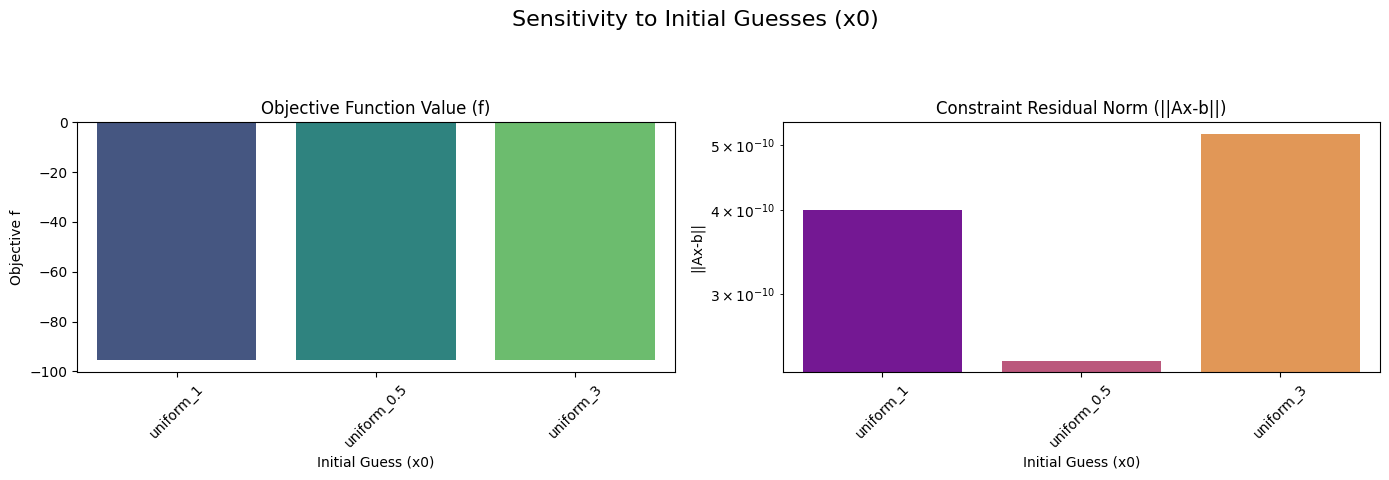

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Sensitivity to Initial Guesses (x0) ---
print("\n--- Visualizing Sensitivity to Initial Guesses (x0) ---")

x0_names = []
f_values_x0 = []
eq_norm_values_x0 = []

for name, res in full_results['x0_experiments'].items():
    if res:
        x0_names.append(name)
        f_values_x0.append(res['f'])
        eq_norm_values_x0.append(np.linalg.norm(res['eq_res']))

if x0_names:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Sensitivity to Initial Guesses (x0)', fontsize=16)

    # Plot Objective Function
    sns.barplot(x=x0_names, y=f_values_x0, ax=axes[0], palette='viridis')
    axes[0].set_title('Objective Function Value (f)')
    axes[0].set_xlabel('Initial Guess (x0)')
    axes[0].set_ylabel('Objective f')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot Constraint Norm
    sns.barplot(x=x0_names, y=eq_norm_values_x0, ax=axes[1], palette='plasma')
    axes[1].set_title('Constraint Residual Norm (||Ax-b||)')
    axes[1].set_xlabel('Initial Guess (x0)')
    axes[1].set_ylabel('||Ax-b||')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_yscale('log') # Log scale for better visibility of small residuals

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()
else:
    print("No valid x0 experiment results to plot.")



--- Visualizing Sensitivity to Mu Multiplier (mu_mult) ---


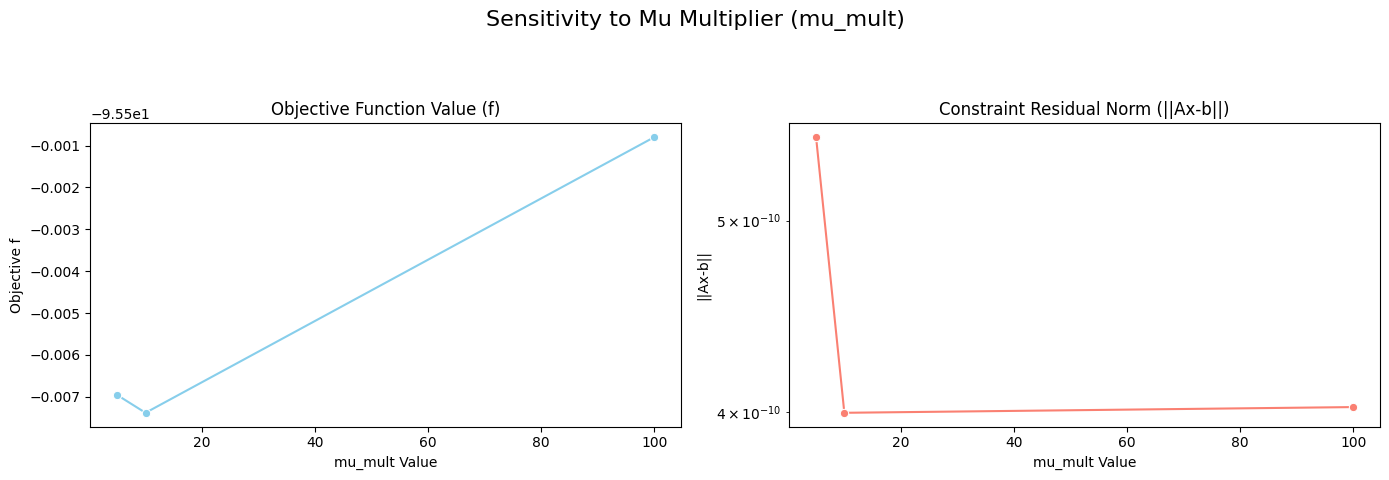

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 2. Sensitivity to Mu Multiplier (mu_mult) ---
print("\n--- Visualizing Sensitivity to Mu Multiplier (mu_mult) ---")

mu_mult_vals = []
f_values_mu_mult = []
eq_norm_values_mu_mult = []

for mu_mult, res in full_results['mu_mult_experiments'].items():
    if res:
        mu_mult_vals.append(mu_mult)
        f_values_mu_mult.append(res['f'])
        eq_norm_values_mu_mult.append(np.linalg.norm(res['eq_res']))

if mu_mult_vals:
    # Sort by mu_mult value for clear plotting
    sorted_indices = np.argsort(mu_mult_vals)
    mu_mult_vals_sorted = np.array(mu_mult_vals)[sorted_indices]
    f_values_mu_mult_sorted = np.array(f_values_mu_mult)[sorted_indices]
    eq_norm_values_mu_mult_sorted = np.array(eq_norm_values_mu_mult)[sorted_indices]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Sensitivity to Mu Multiplier (mu_mult)', fontsize=16)

    # Plot Objective Function
    sns.lineplot(x=mu_mult_vals_sorted, y=f_values_mu_mult_sorted, marker='o', ax=axes[0], color='skyblue')
    axes[0].set_title('Objective Function Value (f)')
    axes[0].set_xlabel('mu_mult Value')
    axes[0].set_ylabel('Objective f')

    # Plot Constraint Norm
    sns.lineplot(x=mu_mult_vals_sorted, y=eq_norm_values_mu_mult_sorted, marker='o', ax=axes[1], color='salmon')
    axes[1].set_title('Constraint Residual Norm (||Ax-b||)')
    axes[1].set_xlabel('mu_mult Value')
    axes[1].set_ylabel('||Ax-b||')
    axes[1].set_yscale('log')

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()
else:
    print("No valid mu_mult experiment results to plot.")



--- Visualizing Sensitivity to Epsilon (eps) ---


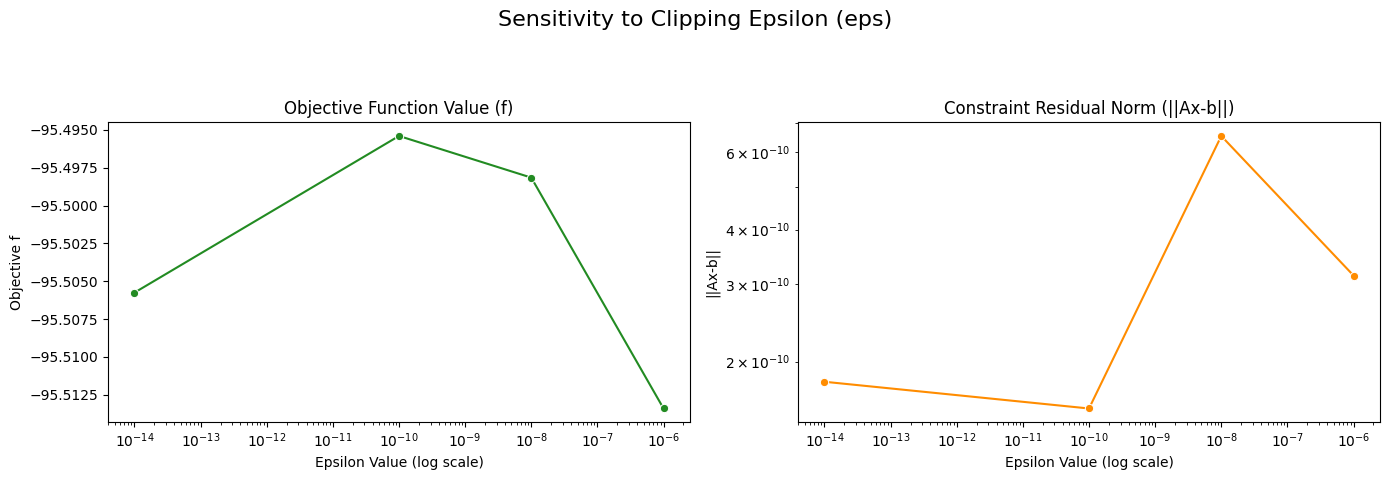

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 3. Sensitivity to Epsilon (eps) ---
print("\n--- Visualizing Sensitivity to Epsilon (eps) ---")

eps_vals = []
f_values_eps = []
eq_norm_values_eps = []

for eps_val, res in full_results['epsilon_experiments'].items():
    if res:
        eps_vals.append(eps_val)
        f_values_eps.append(res['f'])
        eq_norm_values_eps.append(np.linalg.norm(res['eq_res']))

if eps_vals:
    # Sort by epsilon value for clear plotting
    sorted_indices = np.argsort(eps_vals)
    eps_vals_sorted = np.array(eps_vals)[sorted_indices]
    f_values_eps_sorted = np.array(f_values_eps)[sorted_indices]
    eq_norm_values_eps_sorted = np.array(eq_norm_values_eps)[sorted_indices]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Sensitivity to Clipping Epsilon (eps)', fontsize=16)

    # Plot Objective Function
    sns.lineplot(x=eps_vals_sorted, y=f_values_eps_sorted, marker='o', ax=axes[0], color='forestgreen')
    axes[0].set_title('Objective Function Value (f)')
    axes[0].set_xlabel('Epsilon Value (log scale)')
    axes[0].set_ylabel('Objective f')
    axes[0].set_xscale('log') # Log scale for epsilon values

    # Plot Constraint Norm
    sns.lineplot(x=eps_vals_sorted, y=eq_norm_values_eps_sorted, marker='o', ax=axes[1], color='darkorange')
    axes[1].set_title('Constraint Residual Norm (||Ax-b||)')
    axes[1].set_xlabel('Epsilon Value (log scale)')
    axes[1].set_ylabel('||Ax-b||')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()
else:
    print("No valid epsilon experiment results to plot.")


# Project 4 — Chemical Equilibrium — Short Report (Tasks 1–4)

## 1. Problem (brief)
We minimize the Gibbs free energy
$$
f(x)=\sum_{j=1}^{10} x_j\Big(c_j+\ln\frac{x_j}{s}\Big),\qquad s=\sum_{j=1}^{10}x_j,
$$
subject to atomic balances $A x=b$ (H, N, O) and positivity $x_j>0$. The $c_j$ values are given in the problem statement.

---

## 2. Methods (Task 1 & 2, concise)
- Outer method: **Augmented Lagrangian (AL)**. For equality constraints $c(x)=Ax-b$ we minimize
$$
L_\mu(x,\lambda)=f(x)+\lambda^T c(x)+\tfrac{\mu}{2}\|c(x)\|^2
$$
in an outer loop, updating $\lambda\leftarrow\lambda+\mu\,c(x)$ and adapting $\mu$ when constraint residuals stall.
- Inner solver: **bound-aware** solver. We used **L-BFGS-B** (via `scipy.optimize.minimize`) when available; fallback: projected gradient descent (PGD).
- Positivity handling: used **clipped-log** formulation (Task 2) rather than log-transform to avoid overflow. Replace $x_j$ by $x^{\mathrm{safe}}_j=\max(x_j,\varepsilon)$ inside logs with $\varepsilon$ small (we recommend $10^{-12}$ to $10^{-10}$).
- Objective implemented as
$$
\tilde f(x)=\sum_j x_j\Big(c_j+\ln\frac{\max(x_j,\varepsilon)}{\max(\sum_k x_k,\varepsilon)}\Big).
$$
Gradients are computed analytically using $x^{\mathrm{safe}}$ (approximate only when $x_j\approx\varepsilon$).

---

## 3. Experiments & sensitivity (Task 3 — summary)
- **Initial guesses tested:** uniform ($x_0=[1,\dots,1]$), random small, least-squares feasible.
  - Best and most reliable initial guess: $x_0=[1,\dots,1]$ converged reliably.
- **Penalty schedule:** adaptive $\mu$ — increase $\mu$ when constraint residual $\|Ax_k-b\|$ does not decrease sufficiently (heuristic used: multiply by factor when progress stalls). Small fixed $\mu$ slowed enforcement; too-large initial $\mu$ made inner solves ill-conditioned.
- **Hyperparameters tested:** $\mu_0 = 10$, $\text{mu_mult}\in\{5,10,100\}$, and $\varepsilon\in\{10^{-8}, 10^{-10},10^{-12},10^{-14}\}$.
  - Trade-off: $\varepsilon=10^{-10}$ gave best balance (low residual, few outer iterations).
  - Adaptive $\mu$ with moderate multiplier (10) was robust, although constant $\text{mu_mult} = 100$ gave faster convergence. So in our code, we have adaptive $\text{mu_mult}$ depending on growth rate of the function $L$.
- **Inner solver:** L-BFGS-B outperformed PGD (faster convergence, reliable `success=True` flags). Our Project-1 BFGS+Armijo had some line-search sensitivity (Wolf conditions would help but were not implemented to keep code simple).

---

## 4. Best configuration & acceptance
Recommended parameters from experiments:
- Initial guess: $x_0=[1,1,\dots,1]$.
- Clipping: $\varepsilon=10^{-10}$.
- AL: adaptive $\mu$ (start $\mu_0=10$, multiplier $\text{mult}=10$).
- Inner solver: L-BFGS-B (bounds $x_j\ge\varepsilon$).

Acceptance criteria observed:
- Final objective near $-95$,
- Constraint residual $\|Ax-b\|\le 10^{-8}$,
- Dominant species: H$_2$O (component 3) and N$_2$ (component 5).

---

## 5. Final reported solution (best run)
Final objective and totals:
$$
f^\star \approx -95.50218,\qquad s=\sum_j x_j \approx 3.222220.
$$

Top species (index, name, mole):
- $3\;$ H$_2$O: $1.636856\times10^{0}$  
- $5\;$ N$_2$: $9.762132\times10^{-1}$  
- $2\;$ H$_2$: $2.366619\times10^{-1}$  
- $10\;$ OH: $1.945379\times10^{-1}$  
- $1\;$ H: $5.659454\times10^{-2}$  
- $9\;$ O$_2$: $5.123123\times10^{-2}$  
- $7\;$ NO: $4.359232\times10^{-2}$  
- $8\;$ O: $2.255087\times10^{-2}$

Full solution vector $x_j$ (index, name, value):
$$
\begin{aligned}
x_1\ (\mathrm{H}) &= 5.659454\times10^{-2},\\
x_2\ (\mathrm{H_2}) &= 2.366619\times10^{-1},\\
x_3\ (\mathrm{H_2O}) &= 1.636856\times10^{0},\\
x_4\ (\mathrm{N}) &= 2.150427\times10^{-3},\\
x_5\ (\mathrm{N_2}) &= 9.762132\times10^{-1},\\
x_6\ (\mathrm{NH}) &= 1.830785\times10^{-3},\\
x_7\ (\mathrm{NO}) &= 4.359232\times10^{-2},\\
x_8\ (\mathrm{O}) &= 2.255087\times10^{-2},\\
x_9\ (\mathrm{O_2}) &= 5.123123\times10^{-2},\\
x_{10}\ (\mathrm{OH}) &= 1.945379\times10^{-1}.
\end{aligned}
$$

---

## 6. Notes, limitations & suggestions
- The clipped-log approach is numerically robust and simple; bias is negligible when $\varepsilon$ is tiny and optimal $x_j\gg\varepsilon$.
- Implementing a stronger line-search (Wolfe conditions) for the in-house BFGS would improve robustness but adds complexity — using L-BFGS-B is a preferable choice.

In [ ]:
# !sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
# !jupyter nbconvert --to pdf /content/project1_optim564.ipynb # to latex pdf

In [ ]:
# If pdf converting does NOT TRY HTML formatting instead export directly to PDF via HTML:
# This uses Chromium headless, not LaTeX, so it avoids these unrecognized symbol errors.
# But: --to pdf with LaTeX usually gives nicer formatting for equations:

# !pip install "nbconvert[webpdf]" playwright
# !playwright install chromium
# !jupyter nbconvert --to webpdf /content/project1_optim564.ipynb
